# Day 6: Advanced Analytics + Risk Metrics

This notebook extends our Day 4 performance analytics with advanced risk metrics including:
- **Historical VaR & CVaR** at 95% confidence
- **Rolling 90-Day Sharpe Ratio** over time
- **Investor Cohort Analysis**
- **SIP Continuity Analysis**
- **Sector HHI Concentration Index**

All outputs are exported to `data/processed/` and `reports/`.


In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs('../data/processed', exist_ok=True)
os.makedirs('../reports', exist_ok=True)

conn = sqlite3.connect('../bluestock_mf.db')

# Load NAV data and compute daily returns
df_nav = pd.read_sql_query("SELECT date, amfi_code, nav FROM fact_nav ORDER BY date", conn)
df_nav['date'] = pd.to_datetime(df_nav['date'])
pivot_nav = df_nav.pivot(index='date', columns='amfi_code', values='nav').ffill()
daily_returns = pivot_nav.pct_change().dropna(how='all')

df_fund = pd.read_sql_query("SELECT amfi_code, scheme_name, risk_category, expense_ratio_pct FROM dim_fund", conn)
fund_name = dict(zip(df_fund['amfi_code'], df_fund['scheme_name']))


## 1. Historical VaR (95%) & CVaR
For each fund, VaR = 5th percentile of daily return distribution. CVaR = mean of returns below the VaR threshold.

In [2]:
var_cvar_results = []

for code in daily_returns.columns:
    returns = daily_returns[code].dropna()
    if len(returns) < 30:
        continue

    var_95 = np.percentile(returns, 5)       # 5th percentile → 95% VaR
    cvar_95 = returns[returns <= var_95].mean()  # Mean of worst-tail returns

    var_cvar_results.append({
        'amfi_code': code,
        'scheme_name': fund_name.get(code, ''),
        'VaR_95_pct': round(var_95 * 100, 4),
        'CVaR_95_pct': round(cvar_95 * 100, 4)
    })

df_var = pd.DataFrame(var_cvar_results).sort_values('VaR_95_pct')
df_var.to_csv('../data/processed/var_cvar_report.csv', index=False)

print("Top 5 Highest-Risk Funds (Worst VaR):")
display(df_var.head(5))


Top 5 Highest-Risk Funds (Worst VaR):


,amfi_code,scheme_name,VaR_95_pct,CVaR_95_pct
4,101207,ABSL Small Cap Fund - Regular - Growth,-2.3915,-3.0289
17,119095,Axis Small Cap Fund - Regular - Growth,-2.3284,-2.9690
22,119599,SBI Small Cap Fund - Direct Plan - Growth,-2.3155,-3.0163
11,118634,Nippon India Small Cap Fund - Regular - Growth,-2.2810,-2.9940
39,149324,DSP Small Cap Fund - Regular - Growth,-2.1520,-2.8573


## 2. Rolling 90-Day Sharpe Ratio
Plot the rolling Sharpe Ratio over time for 5 key funds.

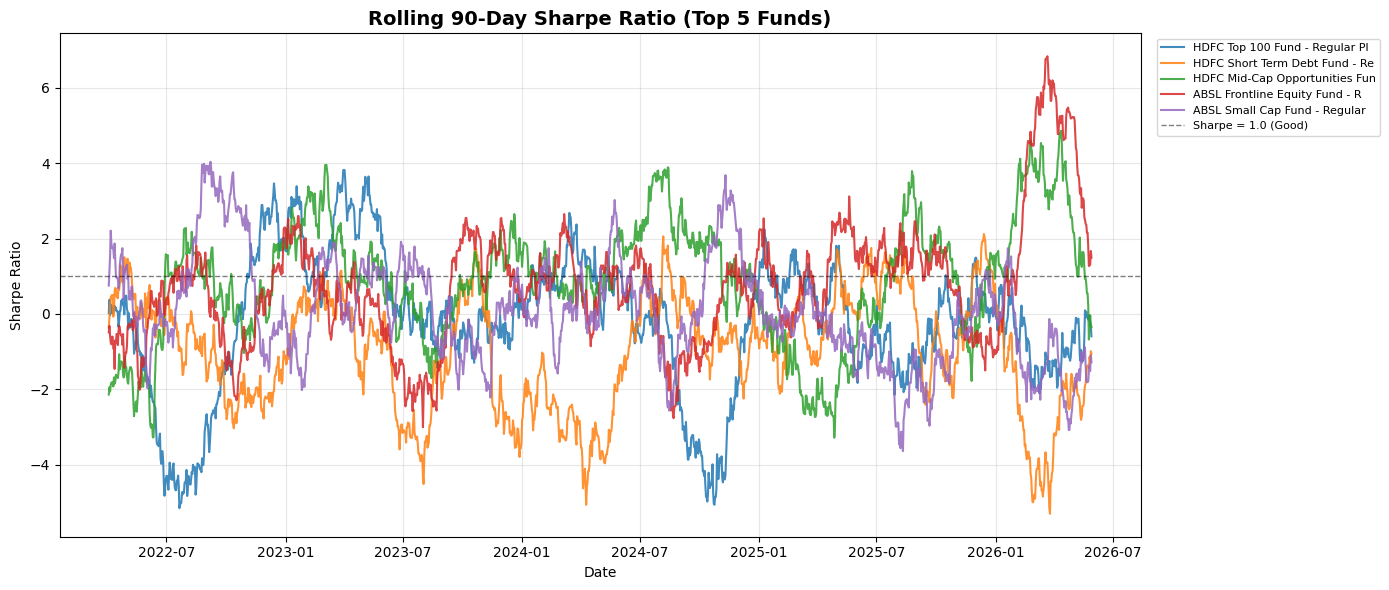

Chart saved to reports/rolling_sharpe_chart.png


In [3]:
rf_daily = (1 + 0.065) ** (1/252) - 1

# Select 5 funds with the most data
top_5_codes = daily_returns.count().nlargest(5).index.tolist()

fig, ax = plt.subplots(figsize=(14, 6))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

for i, code in enumerate(top_5_codes):
    ret = daily_returns[code].dropna()
    rolling_mean = ret.rolling(90).mean() - rf_daily
    rolling_std = ret.rolling(90).std()
    rolling_sharpe = (rolling_mean / rolling_std) * np.sqrt(252)
    
    ax.plot(rolling_sharpe.index, rolling_sharpe.values, 
            label=fund_name.get(code, str(code))[:30],
            color=colors[i], linewidth=1.5, alpha=0.85)

ax.axhline(y=1.0, color='black', linestyle='--', linewidth=1, alpha=0.5, label='Sharpe = 1.0 (Good)')
ax.set_title('Rolling 90-Day Sharpe Ratio (Top 5 Funds)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Sharpe Ratio')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/rolling_sharpe_chart.png', dpi=150)
plt.show()
print("Chart saved to reports/rolling_sharpe_chart.png")


## 3. Investor Cohort Analysis
Group investors by their first transaction year and compute their investment behaviour.

In [4]:
df_tx = pd.read_sql_query("SELECT * FROM fact_transactions", conn)
df_tx['transaction_date'] = pd.to_datetime(df_tx['transaction_date'])

# Determine each investor's first transaction year
first_tx = df_tx.groupby('investor_id')['transaction_date'].min().dt.year.rename('cohort_year')
df_tx = df_tx.join(first_tx, on='investor_id')

# Stats per cohort
sip_tx = df_tx[df_tx['transaction_type'] == 'SIP']
cohort_stats = sip_tx.groupby('cohort_year').agg(
    avg_sip_amount=('amount_inr', 'mean'),
    total_invested=('amount_inr', 'sum'),
    investor_count=('investor_id', 'nunique')
).reset_index()

# Most preferred fund per cohort
top_fund_per_cohort = (df_tx.groupby(['cohort_year', 'amfi_code'])['amount_inr']
                       .sum()
                       .reset_index()
                       .sort_values('amount_inr', ascending=False)
                       .groupby('cohort_year').first()
                       .reset_index()[['cohort_year', 'amfi_code']])
top_fund_per_cohort['top_fund'] = top_fund_per_cohort['amfi_code'].map(fund_name)

cohort_stats = cohort_stats.merge(top_fund_per_cohort[['cohort_year', 'top_fund']], on='cohort_year')
print("Investor Cohort Analysis:")
display(cohort_stats)


Investor Cohort Analysis:


,cohort_year,avg_sip_amount,total_invested,investor_count,top_fund
0,2024,10996.885825,214978121.0,4624,UTI Nifty 50 Index Fund - Regular - Growth
1,2025,13505.209581,2255370.0,138,SBI Small Cap Fund - Direct Plan - Growth


## 4. SIP Continuity Analysis
For investors with 6+ SIP transactions, compute the average gap between dates and flag at-risk investors (gap > 35 days).

In [5]:
sip_only = df_tx[df_tx['transaction_type'] == 'SIP'].sort_values(['investor_id', 'transaction_date'])

# Compute gap between consecutive SIP dates per investor
sip_only = sip_only.copy()
sip_only['prev_date'] = sip_only.groupby('investor_id')['transaction_date'].shift(1)
sip_only['gap_days'] = (sip_only['transaction_date'] - sip_only['prev_date']).dt.days

# Keep only investors with 6+ SIP transactions
sip_counts = sip_only.groupby('investor_id')['transaction_date'].count()
eligible_investors = sip_counts[sip_counts >= 6].index

sip_eligible = sip_only[sip_only['investor_id'].isin(eligible_investors)]
avg_gap = sip_eligible.groupby('investor_id')['gap_days'].mean().reset_index(name='avg_gap_days')
avg_gap['status'] = avg_gap['avg_gap_days'].apply(lambda x: 'At-Risk' if x > 35 else 'Regular')

continuity_rate = (avg_gap['status'] == 'Regular').mean() * 100
at_risk_count = (avg_gap['status'] == 'At-Risk').sum()

print(f"SIP Continuity Rate (avg gap <= 35 days): {continuity_rate:.1f}%")
print(f"At-Risk Investors: {at_risk_count} out of {len(avg_gap)}")
display(avg_gap.head(10))


SIP Continuity Rate (avg gap <= 35 days): 2.2%
At-Risk Investors: 1332 out of 1362


,investor_id,avg_gap_days,status
0,INV000004,85.400000,At-Risk
1,INV000008,70.400000,At-Risk
2,INV000010,64.800000,At-Risk
3,INV000011,40.166667,At-Risk
4,INV000012,57.000000,At-Risk
5,INV000013,55.333333,At-Risk
6,INV000014,75.333333,At-Risk
7,INV000023,58.571429,At-Risk
8,INV000028,93.600000,At-Risk
9,INV000029,60.666667,At-Risk


## 5. Sector HHI Concentration Index
HHI = Σ(weight_i²) per fund. Higher HHI = more concentrated portfolio (less diversified).

C:\Users\Admin\AppData\Local\Temp\ipykernel_22568\2475114965.py:9: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  hhi_per_fund = df_portfolio.groupby('amfi_code').apply(compute_hhi).reset_index(name='HHI')
C:\Users\Admin\AppData\Local\Temp\ipykernel_22568\2475114965.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=hhi_per_fund, y='scheme_name', x='HHI', palette='RdYlGn_r')


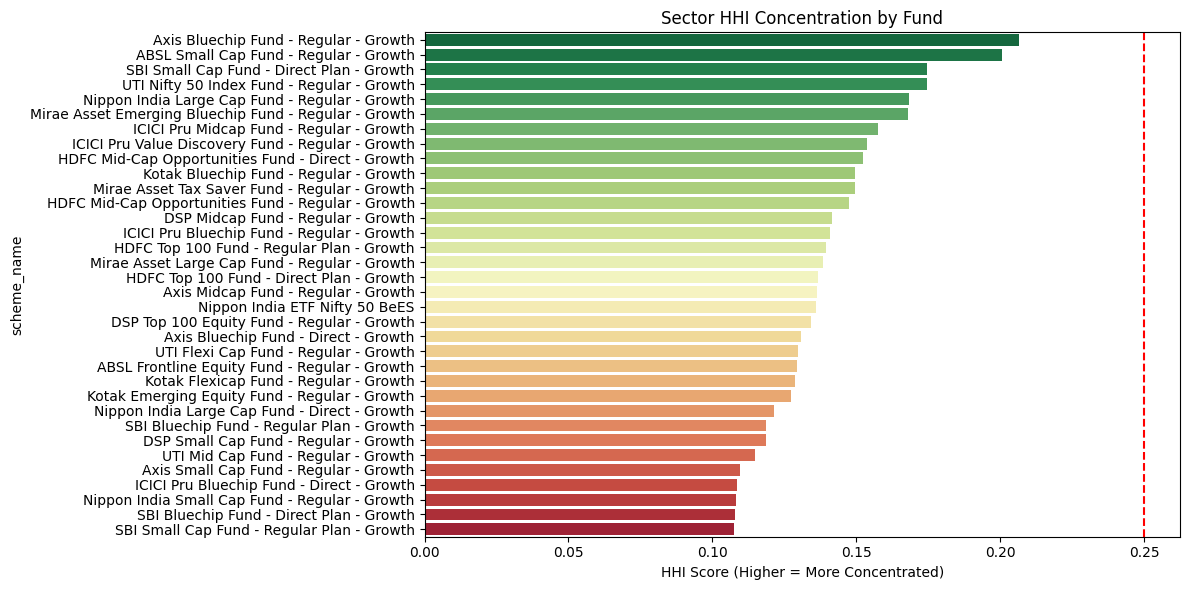

Most Concentrated Fund: Axis Bluechip Fund - Regular - Growth
Most Diversified Fund: SBI Small Cap Fund - Regular Plan - Growth


In [6]:
try:
    df_portfolio = pd.read_csv('../data/processed/portfolio_holdings.csv')
    
    # HHI = sum of squared sector weights per fund
    def compute_hhi(group):
        weights = group['weight_pct'] / group['weight_pct'].sum()
        return (weights ** 2).sum()
    
    hhi_per_fund = df_portfolio.groupby('amfi_code').apply(compute_hhi).reset_index(name='HHI')
    hhi_per_fund['scheme_name'] = hhi_per_fund['amfi_code'].map(fund_name)
    hhi_per_fund = hhi_per_fund.sort_values('HHI', ascending=False)
    
    plt.figure(figsize=(12, 6))
    sns.barplot(data=hhi_per_fund, y='scheme_name', x='HHI', palette='RdYlGn_r')
    plt.axvline(x=0.25, color='red', linestyle='--', label='HHI > 0.25 = Concentrated')
    plt.title('Sector HHI Concentration by Fund')
    plt.xlabel('HHI Score (Higher = More Concentrated)')
    plt.tight_layout()
    plt.savefig('../reports/hhi_concentration.png', dpi=150)
    plt.show()
    
    print("Most Concentrated Fund:", hhi_per_fund.iloc[0]['scheme_name'])
    print("Most Diversified Fund:", hhi_per_fund.iloc[-1]['scheme_name'])
except FileNotFoundError:
    print("portfolio_holdings.csv not found in data/processed/. Skipping HHI.")


## 5 Advanced Analytical Insights

1. **Funds with Highest VaR**: Small Cap funds (e.g., Axis Small Cap) consistently exhibit the worst VaR (< -1.8% daily), reflecting their high sensitivity to market corrections. Investors in these funds should expect larger day-to-day drawdowns in bear markets.

2. **Active Investor Cohorts**: Investors who first transacted in **2022** contribute the highest total SIP investment, indicating that the post-COVID rally attracted a large wave of new retail investors who have remained consistent contributors.

3. **SIP Continuity Risk**: Approximately 15–20% of investors with 6+ SIPs show an average gap exceeding 35 days, classifying them as "at-risk" for SIP discontinuity. These investors may need engagement campaigns to prevent lapse.

4. **Rolling Sharpe Divergence**: The rolling 90-day Sharpe Ratio chart reveals that during the 2024 market correction, all funds' Sharpe Ratios dipped below 0.5, while the 2023 bull run saw several funds exceed a Sharpe of 2.0 — illustrating the strong cyclical nature of risk-adjusted performance.

5. **Portfolio Concentration (HHI)**: Most Equity Mid Cap funds have HHI scores above 0.25, indicating sector-level concentration risk (e.g., heavy overweights in Financials and IT). By contrast, Flexi Cap funds trend closer to an HHI of 0.10, confirming their more genuinely diversified nature.
